In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


 2. Load Dataset

In [2]:

iris = load_iris()   #load iris dataset {150 flower}

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target/species column
df["species"] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


3. Explore Dataset

In [3]:
# Check dataset information

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSpecies Classes:")
print(iris.target_names)

Dataset Shape: (150, 5)

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Species Classes:
['setosa' 'versicolor' 'virginica']


 4. Visualize Dataset

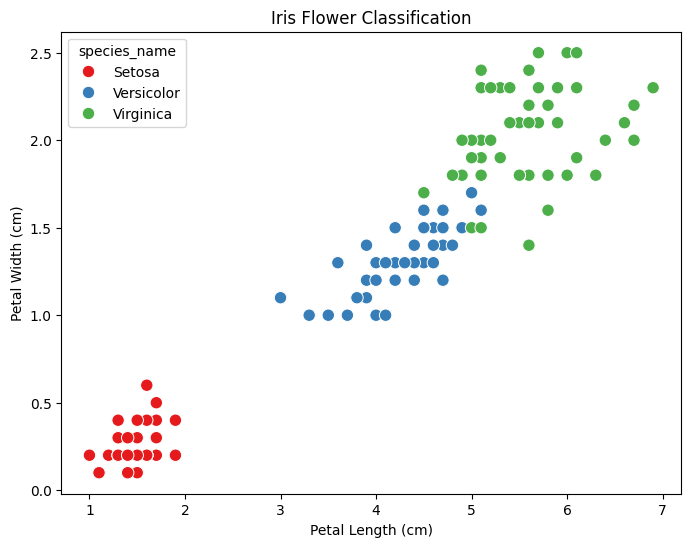

In [4]:
# Add actual species names to the dataset

df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Create a scatter plot

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species_name",
    palette="Set1",
    s=80
)

plt.title("Iris Flower Classification")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.show()

5. Prepare Data

In [5]:
#x= measurement     y= output
# input features
X = iris.data

# Select target labels
y = iris.target

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (150, 4)
Target (y): (150,)


6. Train-Test Split

In [6]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


7. Train SVM

In [7]:
# Create the SVM model
model = SVC(kernel="linear")

# Train the model
model.fit(X_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


8. Make Predictions

In [8]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)


Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


9. Evaluate Model

In [9]:
#model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 1.0
Accuracy Percentage: 100.0 %


10.Classification Report

In [10]:
# Generate classification report

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



11. Confusion Matrix

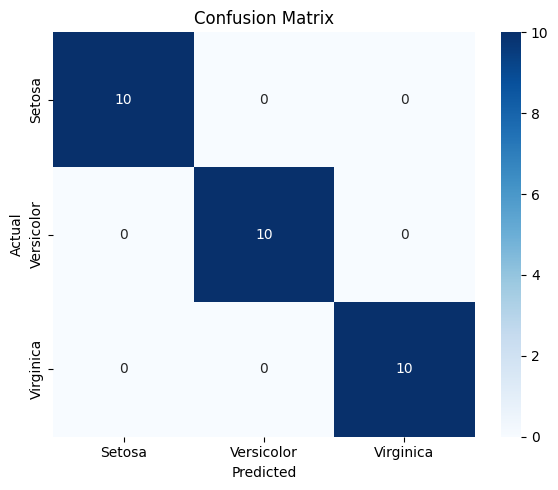

In [11]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Setosa", "Versicolor", "Virginica"],
    yticklabels=["Setosa", "Versicolor", "Virginica"],
    cbar=True
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

12. Predict a New Flower

In [12]:

# Predict Iris flower from user input

sepal_length = float(input("Enter sepal length (cm): "))
sepal_width = float(input("Enter sepal width (cm): "))
petal_length = float(input("Enter petal length (cm): "))
petal_width = float(input("Enter petal width (cm): "))

# Create input array
new_flower = [[
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
]]

# Make prediction
prediction = model.predict(new_flower)

# Display result
print("\nPredicted Flower:", iris.target_names[prediction[0]].upper())

KeyboardInterrupt: Interrupted by user

13. Compare Classification Models

In [ ]:
# Import the required models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="linear")
}

# Store accuracy results
results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    results[name] = accuracy * 100

# Display results
print("Model Accuracy Comparison\n")

for name, accuracy in results.items():
    print(f"{name}: {accuracy:.2f}%")

#Plot model accuracy comparison

plt.figure(figsize=(8, 5))

plt.bar(results.keys(), results.values())

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.ylim(80, 102)
plt.xticks(rotation=20)

plt.show()

 14. 5-Fold Cross-Validation

In [ ]:
# Import cross-validation function
from sklearn.model_selection import cross_val_score

# Perform 5-Fold Cross-Validation

cv_results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results[name] = scores.mean() * 100

    print(f"{name}:")
    print("Fold Accuracies:", scores)
    print(f"Average Accuracy: {scores.mean() * 100:.2f}%")
    print()
    # Plot cross-validation accuracy comparison

plt.figure(figsize=(8, 5))

plt.bar(cv_results.keys(), cv_results.values())

plt.xlabel("Machine Learning Model")
plt.ylabel("Average Accuracy (%)")
plt.title("5-Fold Cross-Validation Model Comparison")

plt.ylim(80, 102)
plt.xticks(rotation=20)

plt.show()

15. Train Final SVM Model

In [ ]:
# Train the final SVM model using the complete dataset

final_model = SVC(kernel="linear")

final_model.fit(X, y)

print("Final SVM model trained successfully!")

16. Save Model

In [ ]:
import pickle

# Save the trained model
with open("iris_svm_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("SVM model saved successfully!")

17. load saved model

In [ ]:
# Load the saved model

with open("iris_svm_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Saved SVM model loaded successfully!")